17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 


D:\Anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step - accuracy: 0.6194 - loss: 0.6405 - val_accuracy: 0.7416 - val_loss: 0.5283
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.8357 - loss: 0.3850 - val_accuracy: 0.7130 - val_loss: 0.5559
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9370 - loss: 0.1787 - val_accuracy: 0.8228 - val_loss: 0.4441
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 158ms/step - accuracy: 0.7884 - loss: 0.4378 - val_accuracy: 0.8662 - val_loss: 0.3228
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.9040 - loss: 0.2482 - val_accuracy: 0.8308 - val_loss: 0.3688
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 154ms/step - accuracy: 0.9348 - loss: 0.1776 - val_accuracy: 0.8510 - val_loss: 0.3324


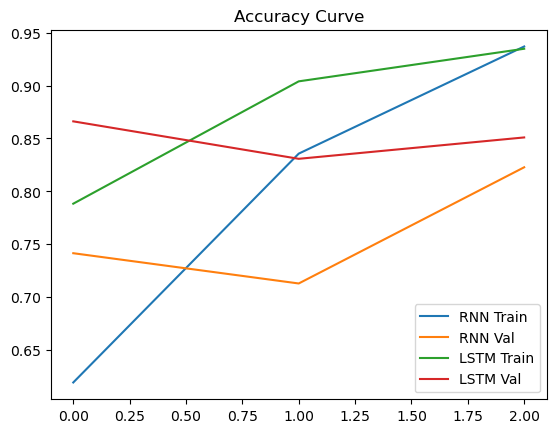

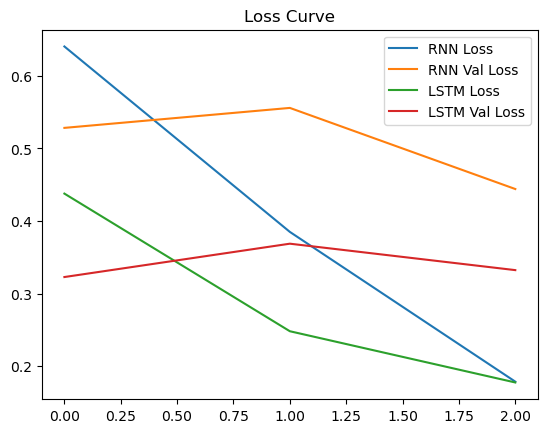

782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step
              precision    recall  f1-score   support

           0       0.83      0.88      0.86     12500
           1       0.88      0.82      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report

# Load IMDB dataset (already tokenized & cleaned)
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Preprocessing: Padding sequences
max_len = 200   # experiment: try 100 also
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# Experiment: Embedding dimension
embedding_dim = 64   # try 128 also

# RNN Model
rnn = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_rnn = rnn.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

# LSTM Model
lstm = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_lstm = lstm.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

# Accuracy graph
plt.plot(hist_rnn.history['accuracy'], label='RNN Train')
plt.plot(hist_rnn.history['val_accuracy'], label='RNN Val')
plt.plot(hist_lstm.history['accuracy'], label='LSTM Train')
plt.plot(hist_lstm.history['val_accuracy'], label='LSTM Val')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss graph
plt.plot(hist_rnn.history['loss'], label='RNN Loss')
plt.plot(hist_rnn.history['val_loss'], label='RNN Val Loss')
plt.plot(hist_lstm.history['loss'], label='LSTM Loss')
plt.plot(hist_lstm.history['val_loss'], label='LSTM Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

# Evaluation
y_pred = (lstm.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step


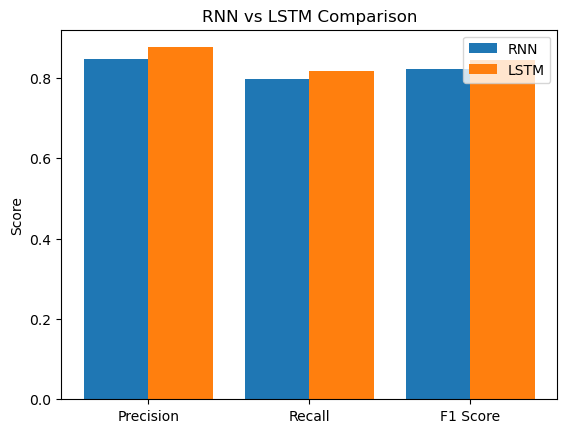

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions
y_pred_rnn = (rnn.predict(X_test) > 0.5).astype(int)
y_pred_lstm = (lstm.predict(X_test) > 0.5).astype(int)

# RNN metrics
precision_rnn = precision_score(y_test, y_pred_rnn)
recall_rnn = recall_score(y_test, y_pred_rnn)
f1_rnn = f1_score(y_test, y_pred_rnn)

# LSTM metrics
precision_lstm = precision_score(y_test, y_pred_lstm)
recall_lstm = recall_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm)

# Labels
metrics = ['Precision', 'Recall', 'F1 Score']

# Values
rnn_values = [precision_rnn, recall_rnn, f1_rnn]
lstm_values = [precision_lstm, recall_lstm, f1_lstm]

# Plot
x = range(len(metrics))

plt.bar(x, rnn_values, width=0.4, label='RNN')
plt.bar([i + 0.4 for i in x], lstm_values, width=0.4, label='LSTM')

plt.xticks([i + 0.2 for i in x], metrics)
plt.title("RNN vs LSTM Comparison")
plt.ylabel("Score")
plt.legend()
plt.show()